In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
data = pd.read_csv("happiness_2017.csv")
data.sample(5)


,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
3,Switzerland,Western Europe,4.0,7.494,7.473593,10.955548,0.949661,73.173759,0.924997,0.167875,0.316183,0.773997,0.195871,0.819707
105,Senegal,Sub-Saharan Africa,106.0,4.535,4.683025,7.811985,0.743759,57.980877,0.686937,-0.029066,0.825242,0.745732,0.290836,0.610723
57,Peru,Latin America and Caribbean,58.0,5.715,5.710937,9.413349,0.830123,65.407242,0.826552,-0.166747,0.895384,0.789391,0.393874,0.254595
2,Iceland,Western Europe,3.0,7.504,7.476214,10.760409,0.966753,72.755981,0.938783,0.235479,0.726845,0.895255,0.148160,0.365042
115,Georgia,Commonwealth of Independent States,116.0,4.286,4.450775,9.169098,0.590495,64.347450,0.820909,-0.231423,0.589632,0.581128,0.209640,0.296396


In [4]:
print("Rows & Columns:", data.shape)
list(data.columns)


Rows & Columns: (145, 14)


['Country',
 'Region',
 'Rank',
 'HappinessScore',
 'Life Ladder',
 'Log GDP per capita',
 'Social support',
 'Healthy life expectancy at birth',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption',
 'Positive affect',
 'Negative affect',
 'Confidence in national government']

In [5]:
num_data = data.select_dtypes(exclude="object")
num_data.describe().T


,count,mean,std,min,25%,50%,75%,max
Rank,140.0,70.500000,40.558600,1.000000,35.750000,70.500000,105.250000,140.000000
HappinessScore,142.0,5.368702,1.159151,1.109750,4.537500,5.302000,6.152250,7.537000
Life Ladder,140.0,5.491702,1.122178,2.661718,4.636694,5.586507,6.278276,7.788252
Log GDP per capita,133.0,9.345615,1.184935,6.625341,8.545789,9.547693,10.313942,11.465231
Social support,139.0,0.806711,0.121117,0.319589,0.736748,0.828953,0.905827,0.966753
Healthy life expectancy at birth,140.0,63.440981,7.595597,44.386528,58.005130,65.209110,69.062944,76.536362
Freedom to make life choices,139.0,0.777874,0.127969,0.427011,0.711635,0.811671,0.878373,0.985178
Generosity,132.0,-0.011614,0.161064,-0.296735,-0.141405,-0.035203,0.098457,0.628706
Perceptions of corruption,128.0,0.735870,0.179799,0.161791,0.681880,0.782116,0.857171,0.954393
Positive affect,139.0,0.699412,0.107246,0.420962,0.614203,0.710230,0.788236,0.895255


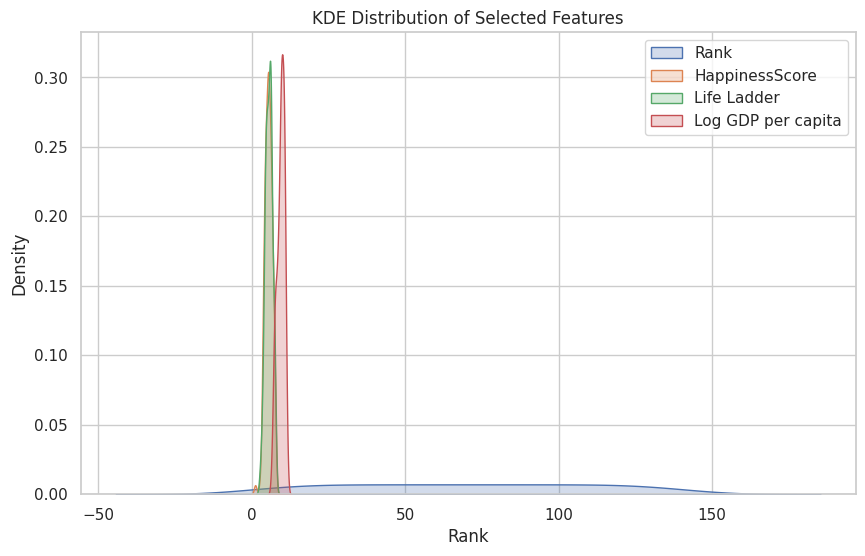

In [6]:
plt.figure(figsize=(10, 6))
for col in num_data.columns[:4]:
    sns.kdeplot(num_data[col], label=col, fill=True)

plt.title("KDE Distribution of Selected Features")
plt.legend()
plt.show()


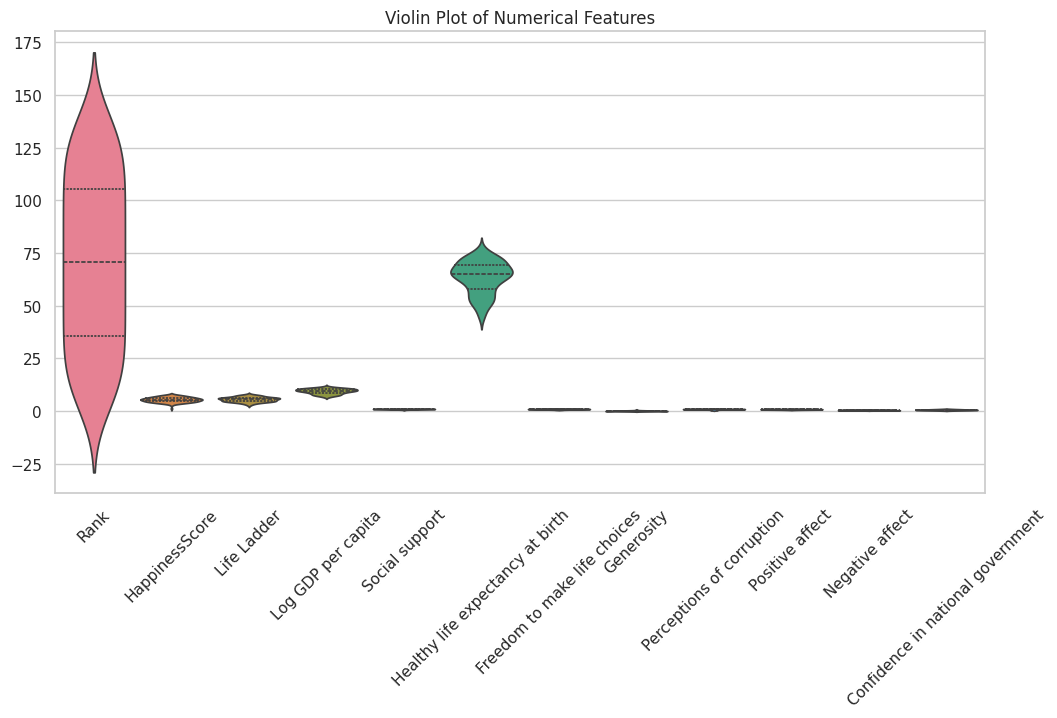

In [7]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=num_data, inner="quartile")
plt.xticks(rotation=45)
plt.title("Violin Plot of Numerical Features")
plt.show()


In [8]:
corr = num_data.corr()
corr


,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
Rank,1.000000,-0.992966,-0.925602,-0.808868,-0.785411,-0.788070,-0.509626,-0.115276,0.473557,-0.534311,0.571605,0.138892
HappinessScore,-0.992966,1.000000,0.930529,0.805027,0.796957,0.790131,0.521046,0.147823,-0.503023,0.530417,-0.585881,-0.124755
Life Ladder,-0.925602,0.930529,1.000000,0.751703,0.756073,0.735743,0.568537,0.168043,-0.495680,0.574558,-0.586886,-0.105585
Log GDP per capita,-0.808868,0.805027,0.751703,1.000000,0.752665,0.856382,0.330385,-0.005600,-0.412119,0.311910,-0.556680,-0.225763
Social support,-0.785411,0.796957,0.756073,0.752665,1.000000,0.718873,0.434546,0.091917,-0.328778,0.452329,-0.661736,-0.162458
Healthy life expectancy at birth,-0.788070,0.790131,0.735743,0.856382,0.718873,1.000000,0.340851,0.018353,-0.374465,0.310637,-0.610326,-0.251910
Freedom to make life choices,-0.509626,0.521046,0.568537,0.330385,0.434546,0.340851,1.000000,0.317580,-0.447542,0.686400,-0.424593,0.436355
Generosity,-0.115276,0.147823,0.168043,-0.005600,0.091917,0.018353,0.317580,1.000000,-0.395848,0.277047,-0.142769,0.410432
Perceptions of corruption,0.473557,-0.503023,-0.495680,-0.412119,-0.328778,-0.374465,-0.447542,-0.395848,1.000000,-0.295075,0.371375,-0.429563
Positive affect,-0.534311,0.530417,0.574558,0.311910,0.452329,0.310637,0.686400,0.277047,-0.295075,1.000000,-0.432584,0.170989


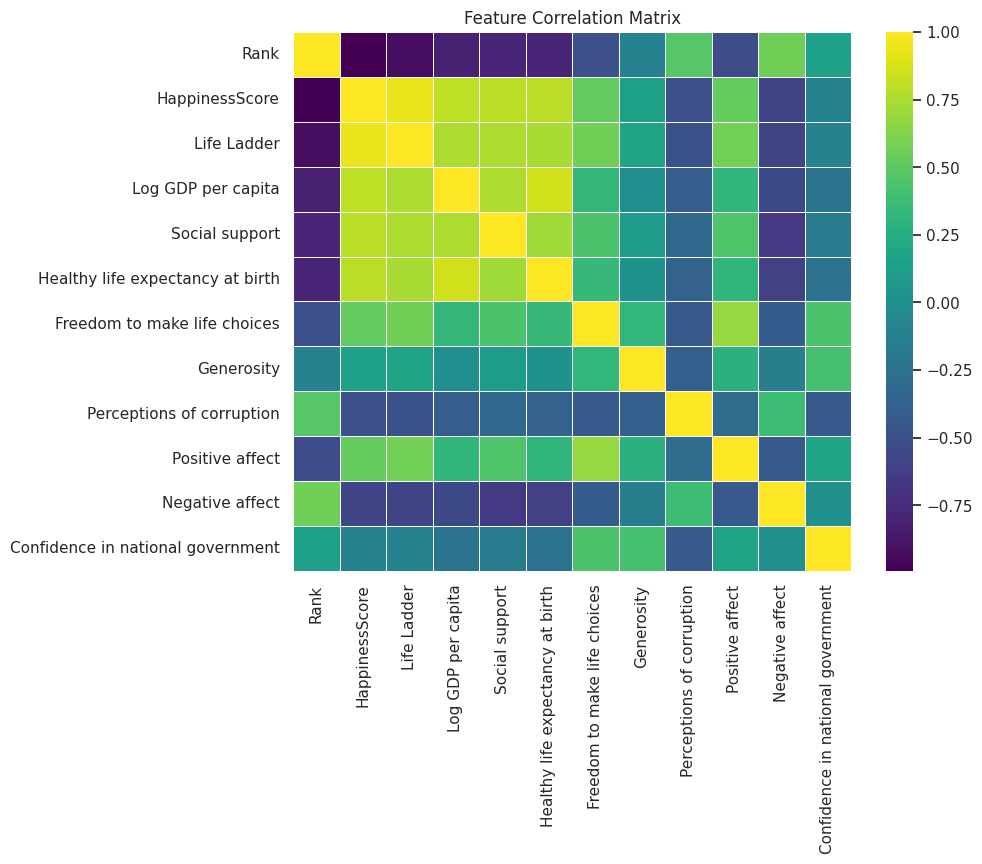

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="viridis", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


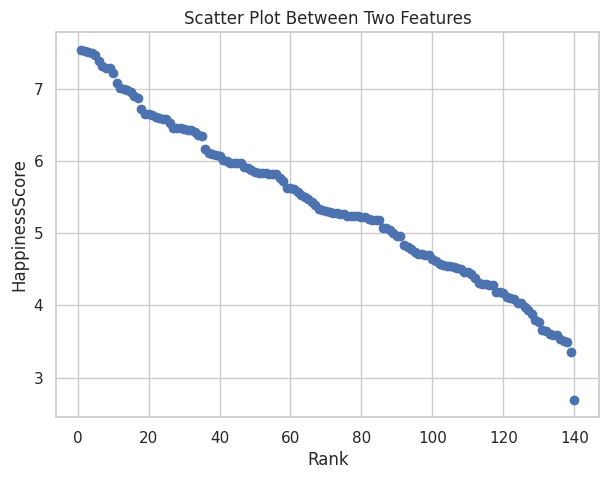

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(
    num_data.iloc[:, 0],
    num_data.iloc[:, 1]
)
plt.xlabel(num_data.columns[0])
plt.ylabel(num_data.columns[1])
plt.title("Scatter Plot Between Two Features")
plt.show()
